<h1 style="color: green;">6.1</h1>

Filename: /Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530

This data structure is a: <class 'numpy.ndarray'>
Its shape should be (NAXIS2, NAXIS1): (530, 530)
(NAXIS2, NAXIS1) are: 530 530
Number of bytes (1byte = 8 bits): >i2 

N=280900 min=1507, max=15752, mean=4795.924268422927, std=1848.2558984219054, Mode: 3551 with 876 counts, Median: 4102.0


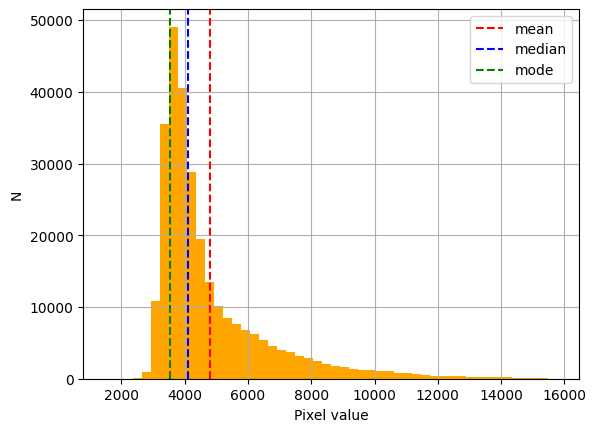

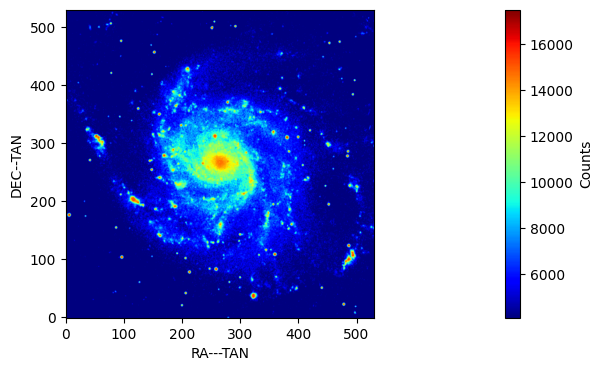

 [astropy.io.fits.verify]


In [209]:
from astropy.io import fits
import numpy as np


hdulist = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits')
hdulist.info()
 # number of HDUs: 2
 # HDU nr of data: 1st
 # number type :int16
    
hdr = hdulist[0].header



for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
 # Bitpix gives 16 which corresponds to the int16 from before


dat = hdulist[0].data
print("\nThis data structure is a:", type(dat))
print("Its shape should be (NAXIS2, NAXIS1):", dat.shape)
print("(NAXIS2, NAXIS1) are:", hdr['NAXIS2'], hdr['NAXIS1'])
print("Number of bytes (1byte = 8 bits):",dat.dtype,'\n')


from scipy import stats

flatdat = dat.flatten()
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(flatdat)
mode, counts = stats.mode(flatdat)
median = np.median(flatdat)
print(f"N={nobs} min={minval}, max={maxval}, mean={mean}, std={var**0.5}, Mode: {mode} with {counts} counts, Median: {median}")


import matplotlib
from matplotlib.pyplot import figure, show
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.hist(flatdat, bins=50, color="orange")
frame.grid()
frame.set_xlabel("Pixel value")
frame.set_ylabel("N")
frame.axvline(mean, ls='--', color='r', label = 'mean')
frame.axvline(median, ls='--', color='b', label = 'median')
frame.axvline(mode, ls='--', color='g', label = 'mode')
frame.legend()

array = np.asarray(dat)
medianar = np.median(array)

from matplotlib.pyplot import figure, show

fig = figure(figsize=(115,4))
frame = fig.add_subplot(1,3,1)
plt.imshow(array, origin="lower", cmap='jet', vmin=median, vmax=17500)
frame.set_xlabel(hdr["CTYPE1"])
frame.set_ylabel(hdr["CTYPE2"])

hdr['BUNIT'] = 'Counts'

plt.colorbar(label = hdr['BUNIT'])
plt.show()


hdulistout = fits.PrimaryHDU(array)
hdulistout.header = hdr    # We can copy the old header
hdulistout.writeto('New.fits', overwrite=True, output_verify='ignore')



hdulist.close()



<h1 style="color: black;">6.2</h1>

<h1 style="color: green;">6.3</h1>

In [156]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show
import math

hdulist = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits')

hdulist.info()
dat = hdulist[0].data
dataa = np.asarray(dat, dtype = float )
data = dataa[:20,:20]


xRMS = ((1/400) * (np.sum(data**2)))**0.5
print(xRMS,np.mean(data))
mean = np.mean(data)
stdev = np.std(data)
print(mean,stdev)

# xRMS is better because it considers the mean, since noise are extremes above or below the mean we need the xrms for that and not the std

Filename: /Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
3432.752866505248 3422.8825
3422.8825 260.1300322795313


<h1 style="color: green;">6.5</h1>

9.98401556679484 10.003955116338458 9.995349488722516
5.773191380233297
5.770294583366139


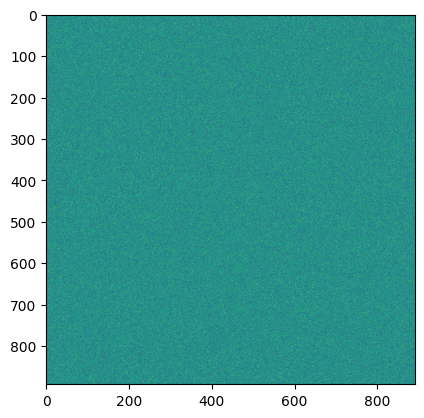

In [175]:
map0 = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/noisemap0.fits')
map1 = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/noisemap1.fits')
map2 = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/noisemap2.fits')

dat0 = map0[0].data
dat1 = map1[0].data
dat2 = map2[0].data

stdev0 = np.std(dat0)
stdev1 = np.std(dat1)
stdev2 = np.std(dat2)
print(stdev0, stdev1, stdev2)

stacked = np.stack((dat0,dat1,dat2),axis=2)
#print(stacked)
meanstack = stacked.mean(axis=2)

fig = plt.figure()
plt.imshow(meanstack)

meanstackflat = meanstack.flatten()
stdstackflat = np.std(meanstackflat)
print(stdstackflat)

stdev = (1/3) * math.sqrt(stdev0**2 +stdev1**2+stdev2**2)
print(stdev)

<h1 style="color: red;">6.6</h1>

In [208]:
from astropy.io import fits
from astropy.table import Table

# Open the FITS file
hdul = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
print(colnames)
# for an image you have pixels in the extension and for a table its columns and rows
mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)
data = Table(data)
dataflag = np.zeros(len(data),dtype=int)
dataflag[mask]=1
table 

['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR']


TypeError: 'module' object is not callable

In [8]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

hdul = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/APOGEE_stars.fits')

data = Table(hdul[1].data) # Convert data into editable table

# if all conditions are met mask will give true and otherwise false
mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)
# Add as a new column
data['DATAFLAG'] = mask.astype(int) # .astype makes true int1 and false integer 0 so add column dataflag with the list of 0s and 1s

# Check with print
print(data.colnames)
print(data['DATAFLAG'][:10])


# Distance in parsecs
distance_pc =1000/ data['GAIAEDR3_PARALLAX']  # Use parallax from data

# Absolute magnitude
absolute_mag = np.where(data['DATAFLAG'] == 1, data['GAIAEDR3_PHOT_G_MEAN_MAG'] - 5 * np.log10(distance_pc), -1.0)
# if condition is met calculate with formula otherwise give it as value -1

# Add as a new column
data['ABS_MAG_G'] = absolute_mag
# Check with print
print(data.colnames)
print(data['ABS_MAG_G'][:10])

# Turn table data into new fits file
hdu = fits.BinTableHDU(data)

# Write to new FITS file
hdu.writeto('APOGEE_update.fits', overwrite=True)

['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR', 'DATAFLAG']
DATAFLAG
--------
       0
       0
       0
       0
       1
       0
       1
       0
       0
       0
['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR', 'DATAFLAG', 'ABS_MAG_G']
ABS_MAG_G 
----------
      -1.0
      -1.0
      -1.0
      -1.0
-2.2118397
      -1.0
-2.0147276
      -1.0
      -1.0
      -1.0


/tmp/ipykernel_15715/1076956816.py:30: RuntimeWarning: invalid value encountered in log10
  absolute_mag = np.where(data['DATAFLAG'] == 1, data['GAIAEDR3_PHOT_G_MEAN_MAG'] - 5 * np.log10(distance_pc), -1.0)


<h1 style="color: red;">6.7</h1>

Maximum flux: 42489404.0
Row corresponding to maximum flux:
     source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
Average m0: 25.68840037029544


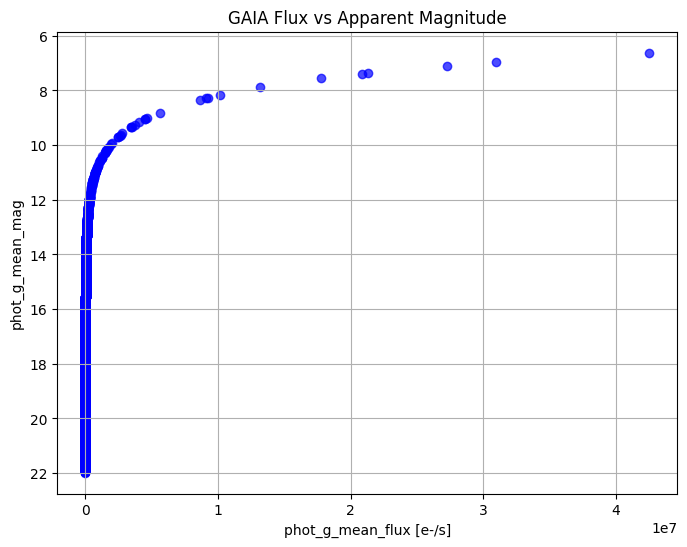

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the csv file with panda
file = pd.read_csv('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/gaiaTestData.csv')

# max flux from file
max_flux = file['phot_g_mean_flux'].max()
# row of max flux
max_flux_row = file[file['phot_g_mean_flux'] == max_flux]
# Print the values and row of the max flux
print("Maximum flux:", max_flux)
print("Row corresponding to maximum flux:\n", max_flux_row)

# sort the whole file by the column photgmeanflux
file_sorted = file.sort_values(by='phot_g_mean_flux', ascending=True)

# Calculate m0 for all stars and take the average
m0_values = file_sorted['phot_g_mean_mag'] + 2.5 * np.log10(file_sorted['phot_g_mean_flux'])
m0_avg = m0_values.mean()
print("Average m0:", m0_avg)

# Use values for x and y in a scatter plot (using the sorted file version)
plt.figure(figsize=(8,6))
plt.scatter(file_sorted['phot_g_mean_flux'], file_sorted['phot_g_mean_mag'], color='blue', alpha=0.7)
plt.xlabel('phot_g_mean_flux [e-/s]')
plt.ylabel('phot_g_mean_mag')
plt.title('GAIA Flux vs Apparent Magnitude')
plt.gca().invert_yaxis()  # Magnitude scale is inverted (bright stars on top)
plt.grid(True)
plt.show()



<h1 style="color: black;">6.9</h1>

<h1 style="color: red;">6.10</h1>

In [18]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.table import Table

# use the top 2000 columns to find the requested columns (also including the give conditions)
query = """
SELECT TOP 2000
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
FROM gaiaedr3.gaia_source
WHERE parallax/parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
"""

# use the query to get the requested columns from Gaia 
do = Gaia.launch_job(query)
results = do.get_results()

# Convert to pandas DataFrame
file = results.to_pandas()

# Randomly select 50 rows in Python using sample
filerando = file.sample(n=50, random_state=42)

# Make table and add all to fitsfile
table = Table.from_pandas(filerando)
table.write("astroquery_gaia.fits", overwrite=True)

<h1 style="color: red;">6.14</h1>

In [20]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""

    def __init__(self):
        self.sequence = [0, 1]
    def nth_term(self, N):
        """
        Returns the N-th Fibonacci number
        """
        while len(self.sequence) <= N:  # as long as the entire sequence of fibonacci is not longer than N
            self.sequence.append(self.sequence[-1] + self.sequence[-2]) # add next fib number
        return self.sequence[N] # if N is reached print the fib number

    def divisible_by(self, N, M):
        """
        Returns all Fibonacci numbers less than the N-th Fibonacci number
        that are divisible by M
        """
        fib_n = self.nth_term(N)  # compute N-th term
        divisible_list = [] # empty list
        a, b = 0, 1 # Starting values
        while a < fib_n: # if starting value is smaller than nth term
            if a % M == 0: # check if divideable
                divisible_list.append(a)
            a, b = b, a + b # calc new fib number
        return divisible_list

# Check with known values

fib = Fibonacci()

nth_100 = fib.nth_term(100)
print("100-th Fibonacci number:", nth_100)

div_by_7 = fib.divisible_by(100, 7)
print("Fibonacci numbers < 100-th term divisible by 7:")
print(div_by_7)

100-th Fibonacci number: 354224848179261915075
Fibonacci numbers < 100-th term divisible by 7:
[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
